<a href="https://colab.research.google.com/github/mmundhe625/dspy1/blob/main/exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. What is 2 tailed and 1 tailed T Test ?

ANS:-

**T-Test Overview:**
A t-test is a statistical hypothesis test used to determine if there is a significant difference between the means of two groups. It's often used when the sample size is small (typically less than 30) and the population standard deviation is unknown.

**1-tailed T-Test (One-sided T-Test):**
*   **Purpose:** A 1-tailed t-test is used when you have a specific direction in mind for your hypothesis. You are testing if one mean is *greater than* or *less than* the other mean.
*   **Hypotheses:**
    *   **Null Hypothesis (H0):** There is no difference, or the difference is in the opposite direction of your hypothesis.
    *   **Alternative Hypothesis (Ha):** The mean of group A is significantly greater than the mean of group B (or vice versa).
*   **Example:** You want to test if a new drug increases test scores. Your alternative hypothesis would be that the scores with the new drug are *greater than* the scores without it.
*   **Rejection Region:** The critical region for rejecting the null hypothesis is entirely in one tail of the t-distribution.

**2-tailed T-Test (Two-sided T-Test):**
*   **Purpose:** A 2-tailed t-test is used when you want to determine if there is *any* significant difference between two group means, regardless of the direction. You are testing if the means are simply *different* from each other.
*   **Hypotheses:**
    *   **Null Hypothesis (H0):** There is no difference between the two group means.
    *   **Alternative Hypothesis (Ha):** The two group means are significantly different from each other (either group A > group B or group A < group B).
*   **Example:** You want to test if a new teaching method has an *effect* on student performance (it could be better or worse). Your alternative hypothesis would be that the performance with the new method is *different from* the old method.
*   **Rejection Region:** The critical region for rejecting the null hypothesis is split between both tails of the t-distribution.

In [ ]:
import numpy as np
from scipy import stats

sample1 = np.random.normal(loc=70, scale=10, size=30)
sample2 = np.random.normal(loc=75, scale=10, size=30)

print(f"Sample 1 (Control) Mean: {np.mean(sample1):.2f}")
print(f"Sample 2 (Treatment) Mean: {np.mean(sample2):.2f}\n")

print("--- 2-tailed Independent T-Test ---")
t_stat_2tail, p_value_2tail = stats.ttest_ind(sample1, sample2, equal_var=True)

print(f"T-statistic (2-tailed): {t_stat_2tail:.3f}")
print(f"P-value (2-tailed): {p_value_2tail:.3f}")

alpha = 0.05
if p_value_2tail < alpha:
    print("Conclusion: Reject the null hypothesis. There is a significant difference between the two sample means.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant significant difference between the two sample means.")

print("\n" + "="*40 + "\n")

print("--- 1-tailed Independent T-Test (Sample 2 > Sample 1) ---")

t_stat_1tail, p_value_temp = stats.ttest_ind(sample1, sample2, equal_var=True)

if t_stat_1tail > 0:
    p_value_1tail = p_value_temp / 2
else:
    p_value_1tail = 1 - (p_value_temp / 2)

print(f"T-statistic (1-tailed): {t_stat_1tail:.3f}")
print(f"P-value (1-tailed, Sample 2 > Sample 1): {p_value_1tail:.3f}")

if p_value_1tail < alpha:
    print("Conclusion: Reject the null hypothesis. The mean of Sample 2 is significantly greater than the mean of Sample 1.")
else:
    print("Conclusion: Fail to reject the null hypothesis. The mean of Sample 2 is not significantly greater than the mean of Sample 1.")

Sample 1 (Control) Mean: 70.13
Sample 2 (Treatment) Mean: 74.80

--- 2-tailed Independent T-Test ---
T-statistic (2-tailed): -1.901
P-value (2-tailed): 0.062
Conclusion: Fail to reject the null hypothesis. There is no significant significant difference between the two sample means.


--- 1-tailed Independent T-Test (Sample 2 > Sample 1) ---
T-statistic (1-tailed): -1.901
P-value (1-tailed, Sample 2 > Sample 1): 0.969
Conclusion: Fail to reject the null hypothesis. The mean of Sample 2 is not significantly greater than the mean of Sample 1.


2. Explain what is Type I and Type II errors with an example.

ANS:-

In hypothesis testing, we make decisions about a population based on sample data. There's always a risk that our conclusions might be incorrect. These potential errors are categorized into two types:

**Type I Error (False Positive):**
*   **Definition:** A Type I error occurs when you **reject a true null hypothesis**. In simpler terms, you conclude that there is a significant effect or difference when, in reality, there isn't.
*   **Symbol:** It is denoted by the Greek letter alpha (α), which is also the significance level of the test.
*   **Risk:** The probability of committing a Type I error is equal to the significance level (α). For example, if α = 0.05, there is a 5% chance of making a Type I error.
*   **Analogy/Example:** Imagine a medical test for a disease. A Type I error would be diagnosing someone with the disease when they are actually healthy (a false positive).
    *   **Null Hypothesis (H0):** The patient does not have the disease.
    *   **Alternative Hypothesis (Ha):** The patient has the disease.
    *   **Type I Error:** Concluding the patient has the disease (reject H0) when they are actually healthy (H0 is true).

**Type II Error (False Negative):**
*   **Definition:** A Type II error occurs when you **fail to reject a false null hypothesis**. In simpler terms, you conclude that there is no significant effect or difference when, in reality, there is one.
*   **Symbol:** It is denoted by the Greek letter beta (β).
*   **Risk:** The probability of committing a Type II error (β) is inversely related to the power of the test (1 - β). Increasing the sample size often helps reduce β.
*   **Analogy/Example:** Using the same medical test example, a Type II error would be telling someone they are healthy when they actually have the disease (a false negative).
    *   **Null Hypothesis (H0):** The patient does not have the disease.
    *   **Alternative Hypothesis (Ha):** The patient has the disease.
    *   **Type II Error:** Concluding the patient does not have the disease (fail to reject H0) when they are actually sick (H0 is false).

3. What is power of statistical test?

ANS:-

**Power of a Statistical Test:**

The power of a statistical test is the probability that the test will correctly reject a false null hypothesis. In simpler terms, it's the probability of finding a statistically significant effect when an effect actually exists. It is often denoted as **1 - β** (where β is the probability of a Type II error).

**Key Concepts:**

*   **Null Hypothesis (H0):** A statement that there is no effect or no difference.
*   **Alternative Hypothesis (Ha):** A statement that there is an effect or a difference.
*   **Type II Error (β):** Failing to reject a false null hypothesis (a false negative). This means you miss an actual effect.

**Understanding Power:**

*   **High Power (e.g., 0.80 or 80%):** Means there is an 80% chance of detecting a true effect if one exists. This is generally desirable.
*   **Low Power:** Means you have a high chance of committing a Type II error (failing to detect a real effect).

**Factors Affecting Power:**

1.  **Sample Size:** Larger sample sizes generally lead to higher power, as they provide more information and reduce sampling error.
2.  **Effect Size:** A larger effect size (the magnitude of the difference or relationship you are trying to detect) makes it easier to detect the effect, thus increasing power.
3.  **Significance Level (α):** A higher α (e.g., 0.10 instead of 0.05) increases power, but also increases the risk of a Type I error (false positive).
4.  **Variability:** Less variability (smaller standard deviation) in the data increases power, as it makes the effect clearer.
5.  **Type of Test:** Some statistical tests are inherently more powerful than others for specific data distributions or research questions.

**Importance:**

Power analysis is crucial in research design to determine the appropriate sample size needed to detect a statistically significant effect of a given magnitude. A study with insufficient power might fail to detect an important effect, leading to wasted resources and potentially misleading conclusions.


--- Power Analysis: Determining Required Sample Size ---
Desired Power: 80%
Significance Level (alpha): 0.05
Expected Effect Size (Cohen's d): 0.5
Required sample size per group (n): 64

--- Power Analysis: Calculating Power for a Given Sample Size ---
Sample size per group: 30
Expected Effect Size (Cohen's d): 0.5
Power to detect this effect: 47.79%



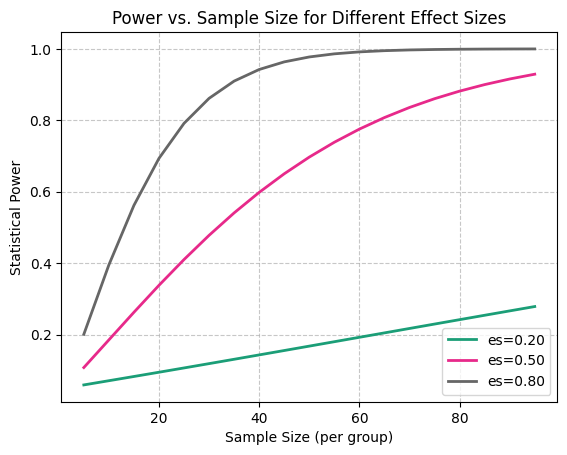

In [ ]:
import numpy as np
from statsmodels.stats.power import TTestIndPower
from scipy import stats

alpha = 0.05
effect_size = 0.5
ratio = 1.0
power = 0.80

print(f"--- Power Analysis: Determining Required Sample Size ---")
print(f"Desired Power: {power*100:.0f}%")
print(f"Significance Level (alpha): {alpha}")
print(f"Expected Effect Size (Cohen's d): {effect_size}")

analysis = TTestIndPower()

required_n = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=ratio,
    alternative='two-sided'
)

print(f"Required sample size per group (n): {np.ceil(required_n):.0f}\n")

sample_size_per_group = 30

power_given_n = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    nobs1=sample_size_per_group,
    ratio=ratio,
    alternative='two-sided'
)

print(f"--- Power Analysis: Calculating Power for a Given Sample Size ---")
print(f"Sample size per group: {sample_size_per_group}")
print(f"Expected Effect Size (Cohen's d): {effect_size}")
print(f"Power to detect this effect: {power_given_n*100:.2f}%\n")

import matplotlib.pyplot as plt

fig = analysis.plot_power(
    dep_var='nobs',
    nobs=np.arange(5, 100, 5),
    effect_size=np.array([0.2, 0.5, 0.8]),
    alpha=0.05,
    title='Power vs. Sample Size for Different Effect Sizes'
)
plt.ylabel('Statistical Power')
plt.xlabel('Sample Size (per group)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

4.  Explain input and out put characteristics for  stats.ttest_rel function in your own words


ANS:-



## `stats.ttest_rel` Function: Input and Output Characteristics

The `scipy.stats.ttest_rel` function is used to perform a **paired (or dependent) samples t-test**. This test is appropriate when you have two measurements from the *same* subjects or matched pairs, and you want to determine if there is a statistically significant difference between the means of these two related sets of observations.

### Inputs (Parameters):

1.  **`a`**: The first array of observations (e.g., scores before a treatment). It should be an array-like object (e.g., a NumPy array or a list of numbers).
    *   **Characteristic**: Represents one set of paired measurements.

2.  **`b`**: The second array of observations (e.g., scores after a treatment). It should also be an array-like object.
    *   **Characteristic**: Represents the second set of paired measurements. Crucially, `a` and `b` must have the same length, and each element `a[i]` is paired with `b[i]` (e.g., `a[i]` is the 'before' score for subject `i`, and `b[i]` is the 'after' score for subject `i`).

3.  **`axis`** (optional): The axis along which to compute the test. If not specified (default is `0`), the test is computed along the first axis. If `None`, the input arrays are flattened, and the test is performed on all elements.
    *   **Characteristic**: Useful for multi-dimensional arrays if you want to perform tests across rows or columns.

4.  **`nan_policy`** (optional): Defines how to handle input NaNs.
    *   `'propagate'` (default): Returns NaN if NaN is present in the inputs.
    *   `'raise'`: Raises an error if NaN is present.
    *   `'omit'`: Performs the calculations ignoring NaN values (requires corresponding elements in both `a` and `b` to be non-NaN).
    *   **Characteristic**: Provides flexibility in how missing data is managed.

5.  **`alternative`** (optional): Defines the alternative hypothesis.
    *   `'two-sided'` (default): Tests if the means are different (μ1 ≠ μ2).
    *   `'less'`: Tests if the mean of `a` is less than the mean of `b` (μ1 < μ2).
    *   `'greater'`: Tests if the mean of `a` is greater than the mean of `b` (μ1 > μ2).
    *   **Characteristic**: Allows for one-tailed or two-tailed tests based on the research question's directionality.

### Outputs (Return Values):

The `ttest_rel` function returns a `Ttest_relResult` object, which is a named tuple containing:

1.  **`statistic`**: The calculated t-statistic.
    *   **Characteristic**: This value quantifies the magnitude of the difference between the sample means relative to the variation within the samples. A larger absolute t-statistic suggests a larger difference between the means.

2.  **`pvalue`**: The p-value associated with the t-statistic.
    *   **Characteristic**: The probability of observing a t-statistic as extreme as, or more extreme than, the one calculated, assuming the null hypothesis is true. A small p-value (typically < 0.05) leads to the rejection of the null hypothesis, suggesting a significant difference between the paired means.

In [ ]:
import numpy as np
from scipy import stats

before_scores = np.array([75, 80, 65, 70, 85, 90, 78, 82, 60, 72, 77, 81, 68, 73, 88])
after_scores = np.array([78, 85, 70, 75, 88, 92, 80, 85, 65, 75, 80, 83, 70, 76, 90])

print(f"Mean 'Before' scores: {np.mean(before_scores):.2f}")
print(f"Mean 'After' scores: {np.mean(after_scores):.2f}\n")

t_statistic_2sided, p_value_2sided = stats.ttest_rel(before_scores, after_scores, alternative='two-sided')

print("--- Paired Samples T-Test (Two-sided) ---")
print(f"T-statistic: {t_statistic_2sided:.3f}")
print(f"P-value: {p_value_2sided:.3f}")

alpha = 0.05
if p_value_2sided < alpha:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in scores before and after the program.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in scores before and after the program.")

print("\n" + "="*60 + "\n")

t_statistic_greater, p_value_greater = stats.ttest_rel(before_scores, after_scores, alternative='less')

print("--- Paired Samples T-Test (One-sided: After > Before) ---")
print(f"T-statistic: {t_statistic_greater:.3f}")
print(f"P-value: {p_value_greater:.3f}")

if p_value_greater < alpha:
    print("Conclusion: Reject the null hypothesis. 'After' scores are significantly greater than 'Before' scores.")
else:
    print("Conclusion: Fail to reject the null hypothesis. 'After' scores are not significantly greater than 'Before' scores.")

Mean 'Before' scores: 76.27
Mean 'After' scores: 79.47

--- Paired Samples T-Test (Two-sided) ---
T-statistic: -10.267
P-value: 0.000
Conclusion: Reject the null hypothesis. There is a significant difference in scores before and after the program.


--- Paired Samples T-Test (One-sided: After > Before) ---
T-statistic: -10.267
P-value: 0.000
Conclusion: Reject the null hypothesis. 'After' scores are significantly greater than 'Before' scores.


5. What is function in stats module for identifying power of a statistical test. Explain out put range of it and its significance.


ANS:-



--- Power Analysis: Determining Required Sample Size ---
Desired Power: 80%
Significance Level (alpha): 0.05
Expected Effect Size (Cohen's d): 0.5
Required sample size per group (n): 64

--- Power Analysis: Calculating Power for a Given Sample Size ---
Sample size per group: 30
Expected Effect Size (Cohen's d): 0.5
Power to detect this effect: 47.79%



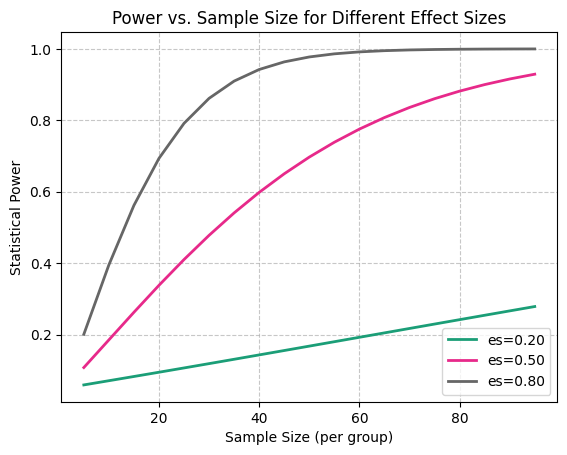

In [ ]:
import numpy as np
from statsmodels.stats.power import TTestIndPower

alpha = 0.05
effect_size = 0.5
power = 0.80
ratio = 1.0

print(f"--- Power Analysis: Determining Required Sample Size ---")
print(f"Desired Power: {power*100:.0f}%")
print(f"Significance Level (alpha): {alpha}")
print(f"Expected Effect Size (Cohen's d): {effect_size}")

analysis = TTestIndPower()

required_n = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=ratio,
    alternative='two-sided'
)

print(f"Required sample size per group (n): {np.ceil(required_n):.0f}\n")

sample_size_per_group = 30

power_given_n = analysis.solve_power(
    effect_size=effect_size,
    alpha=alpha,
    nobs1=sample_size_per_group,
    ratio=ratio,
    alternative='two-sided'
)

print(f"--- Power Analysis: Calculating Power for a Given Sample Size ---")
print(f"Sample size per group: {sample_size_per_group}")
print(f"Expected Effect Size (Cohen's d): {effect_size}")
print(f"Power to detect this effect: {power_given_n*100:.2f}%\n")

import matplotlib.pyplot as plt

fig = analysis.plot_power(
    dep_var='nobs',
    nobs=np.arange(5, 100, 5),
    effect_size=np.array([0.2, 0.5, 0.8]),
    alpha=0.05,
    title='Power vs. Sample Size for Different Effect Sizes'
)
plt.ylabel('Statistical Power')
plt.xlabel('Sample Size (per group)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()